# Manual Round 5 — Ignith PnL Curves

Fee formula: `fee = (v_pct/100)^2 * B`  →  with `v` as a fraction in [0, 1]:

$$\text{PnL}(v, r) = v \cdot B \cdot r \;-\; v^2 \cdot B$$

Optimum (per asset, ignoring budget constraint): $v^* = r/2$, peak PnL $= (r/2)^2 \cdot B = v^{*2} \cdot B$.

In [34]:
import numpy as np
import matplotlib.pyplot as plt

B = 1_000_000

def pnl(v, r, B=B):
    return v * B * r - v**2 * B

## Plot 1 — PnL vs volume fraction for a single expected return

Using $r = 0.30$ (e.g. Thermalite Core estimate). Optimal $v^* = 0.15$.

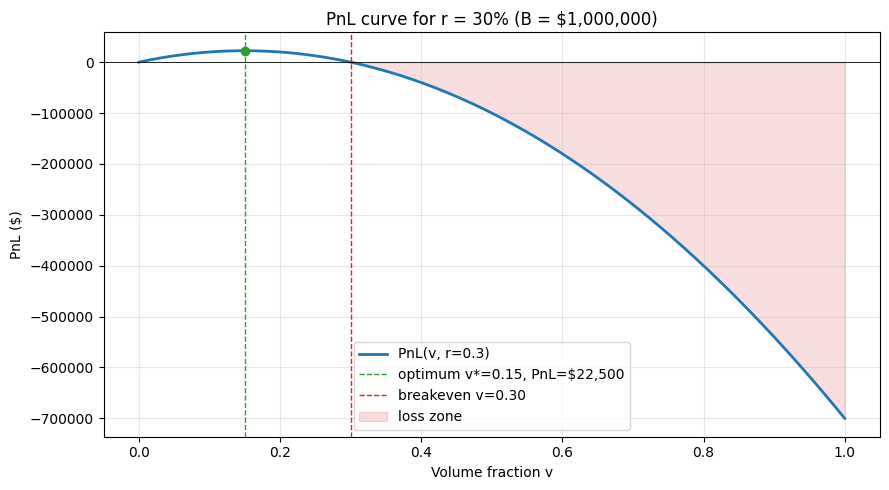

In [35]:
r = 0.30
v = np.linspace(0, 1, 500)
y = pnl(v, r)

v_star = r / 2
pnl_star = pnl(v_star, r)
v_breakeven = r

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(v, y, lw=2, label=f'PnL(v, r={r})')
ax.axhline(0, color='k', lw=0.6)
ax.axvline(v_star, color='C2', ls='--', lw=1, label=f'optimum v*={v_star:.2f}, PnL=${pnl_star:,.0f}')
ax.axvline(v_breakeven, color='C3', ls='--', lw=1, label=f'breakeven v={v_breakeven:.2f}')
ax.scatter([v_star], [pnl_star], color='C2', zorder=5)
ax.fill_between(v, y, 0, where=(y < 0), color='C3', alpha=0.15, label='loss zone')
ax.set_xlabel('Volume fraction v')
ax.set_ylabel('PnL ($)')
ax.set_title(f'PnL curve for r = {r:.0%} (B = ${B:,})')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Plot 2 — Peak PnL locus across a range of expected returns

For each $r$, the peak sits at $(v^*, \text{PnL}^*) = (r/2,\; v^{*2} \cdot B)$. So in $(v, \text{PnL})$ space, the locus of peaks is the parabola $\text{PnL} = v^2 \cdot B$. Several PnL curves are overlaid to make the envelope visible.

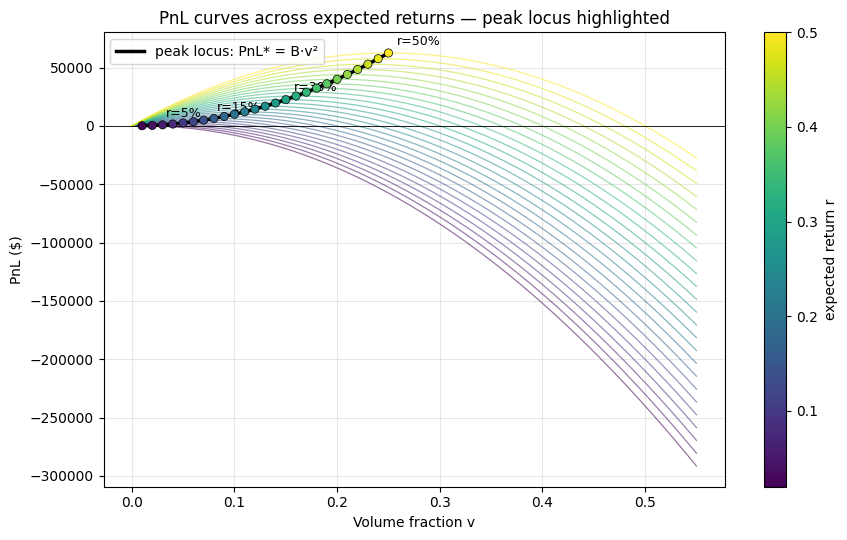

In [36]:
r_grid = np.linspace(0.02, 0.50, 25)
v = np.linspace(0, 0.55, 500)

fig, ax = plt.subplots(figsize=(9, 5.5))

cmap = plt.cm.viridis
for i, r in enumerate(r_grid):
    ax.plot(v, pnl(v, r), color=cmap(i / (len(r_grid) - 1)), lw=0.9, alpha=0.55)

v_peaks = r_grid / 2
pnl_peaks = B * v_peaks**2
ax.plot(v_peaks, pnl_peaks, 'k-', lw=2.5, label='peak locus: PnL* = B·v²')
ax.scatter(v_peaks, pnl_peaks, c=r_grid, cmap='viridis', s=35, zorder=5,
           edgecolor='k', linewidth=0.5)

for r in [0.05, 0.15, 0.30, 0.50]:
    vp = r / 2
    pp = B * vp**2
    ax.annotate(f'r={r:.0%}', (vp, pp), textcoords='offset points',
                xytext=(6, 6), fontsize=9)

ax.axhline(0, color='k', lw=0.6)
ax.set_xlabel('Volume fraction v')
ax.set_ylabel('PnL ($)')
ax.set_title('PnL curves across expected returns — peak locus highlighted')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)

sm = plt.cm.ScalarMappable(cmap='viridis',
                            norm=plt.Normalize(vmin=r_grid.min(), vmax=r_grid.max()))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label('expected return r')

plt.tight_layout()
plt.show()

## Plot 3 — Peak locus over a wide return range: when does 100% volume become optimal?

Peaks live on the curve $v^* = r/2$.  For the unconstrained optimum to *demand* 100% allocation on a single asset, you need $r = 2.0$ (i.e. **+200%** expected return).  This cell extends the peak locus far past the [0,1] volume cap so the threshold is visible.

Three reference lines are added:
- **Forced-100% PnL** (black dashed): what you actually get if you push v=1 regardless of r — equals $B(r-1)$.  Crosses zero at r=100% (you only break even at 100% volume when r=100%).
- **v=1 cap** (red): the budget ceiling.  Optimal peaks left of this line are reachable; peaks to the right are unreachable single-asset optima.
- **r=200% marker**: where the unconstrained peak hits v=1 — the exact return needed to justify going all-in on one name.

**Portfolio interpretation:** for an N-asset portfolio with average return $\bar r$ across names you actually trade, the budget binds when $N \bar r \geq 2$, i.e. $\bar r \geq 2/N$.  With N=9 names that's just **~22% average** — but with N=1 it's 200%.

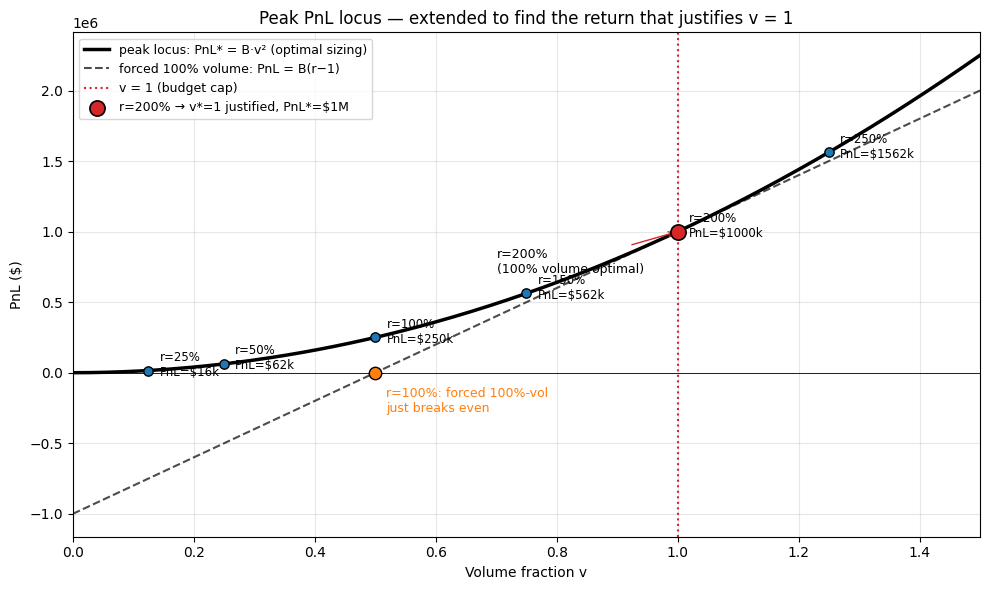

Single-asset optimum reaches v=1 at r = 2.0 (=200%)
Single-asset forced v=1 breaks even at r = 1.0 (=100%)
For an N-asset portfolio with equal sizing, budget binds when avg r ≥ 2/N:
  N= 1:  avg r ≥ 200.0%
  N= 2:  avg r ≥ 100.0%
  N= 3:  avg r ≥ 66.7%
  N= 5:  avg r ≥ 40.0%
  N= 9:  avg r ≥ 22.2%
  N=20:  avg r ≥ 10.0%


In [37]:
v_wide = np.linspace(0, 1.5, 500)
r_wide = 2 * v_wide  # since v* = r/2 on the locus
pnl_locus = B * v_wide**2

# Forced-100% PnL: PnL(v=1, r) = B(r-1).  Plotted in (v, PnL) space at v=1 line — but here we compare
# along the same x-axis (volume) by using v_forced = 1 and varying r.  Show as a horizontal sweep.
r_forced_grid = np.linspace(0, 3.0, 500)
pnl_forced = B * (r_forced_grid - 1)
v_forced_for_plot = r_forced_grid / 2  # plot at the v* that *would* be optimal for that r, for comparison

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(v_wide, pnl_locus, 'k-', lw=2.5, label='peak locus: PnL* = B·v² (optimal sizing)')
ax.plot(v_forced_for_plot, pnl_forced, 'k--', lw=1.5, alpha=0.7,
        label='forced 100% volume: PnL = B(r−1)')

# Mark every 25% of return on the locus
for r_mark in [0.25, 0.50, 1.00, 1.50, 2.00, 2.50]:
    vm = r_mark / 2
    pm = B * vm**2
    ax.scatter([vm], [pm], color='C0', zorder=5, s=45, edgecolor='k')
    ax.annotate(f'r={r_mark:.0%}\nPnL=${pm/1000:.0f}k', (vm, pm),
                textcoords='offset points', xytext=(8, -4), fontsize=8.5)

# v = 1 budget cap
ax.axvline(1.0, color='C3', ls=':', lw=1.5, label='v = 1 (budget cap)')

# The critical point: v*=1 happens at r=200%
ax.scatter([1.0], [B], color='C3', s=120, zorder=6, edgecolor='k', linewidth=1.2,
           label='r=200% → v*=1 justified, PnL*=$1M')
ax.annotate('r=200%\n(100% volume optimal)', (1.0, B),
            textcoords='offset points', xytext=(-130, -30), fontsize=9,
            arrowprops=dict(arrowstyle='->', color='C3'))

# r=100% break-even of forced sizing
ax.scatter([0.5], [0], color='C1', s=80, zorder=6, edgecolor='k')
ax.annotate('r=100%: forced 100%-vol\njust breaks even', (0.5, 0),
            textcoords='offset points', xytext=(8, -28), fontsize=9, color='C1')

ax.axhline(0, color='k', lw=0.6)
ax.set_xlabel('Volume fraction v')
ax.set_ylabel('PnL ($)')
ax.set_title('Peak PnL locus — extended to find the return that justifies v = 1')
ax.legend(loc='upper left', fontsize=9)
ax.grid(alpha=0.3)
ax.set_xlim(0, 1.5)
plt.tight_layout()
plt.show()

print('Single-asset optimum reaches v=1 at r =', 2.0, '(=200%)')
print('Single-asset forced v=1 breaks even at r =', 1.0, '(=100%)')
print('For an N-asset portfolio with equal sizing, budget binds when avg r ≥ 2/N:')
for N in [1, 2, 3, 5, 9, 20]:
    print(f'  N={N:2d}:  avg r ≥ {2/N:.1%}')


## Return estimates per asset

Each estimate is built additively from three components so it's transparent and tweakable:

1. **Archetype prior** — the typical magnitude for that news category (index inclusion, manufacturing halt, regulatory recall, ESG scandal, demand-tax shock, sellout/limited-edition, influencer pump).
2. **Concreteness modifier** — bumps magnitude when the article gives hard numbers (e.g. Thermalite's 1.42M → 3.89M user count) or compounding damage (Lava Cake: halt + lawsuits + vendor returns).
3. **Already-priced-in haircut** — shrinks magnitude when the article says the move has *already* started (Volcanic Incense extending its rally; Scoria pump from a self-described 'market medium').

All three components are stored explicitly in the `assets` dict below so you can override any number and re-run.

In [38]:
# direction: +1 = buy, -1 = sell
# prior, concrete, hype: signed magnitudes (positive numbers stack onto |r|)
# r_hat is computed as direction * (prior + concrete - hype)

assets = {
    'Thermalite Core': {
        'direction': +1,
        'archetype': 'blockbuster forecast (smart-home growth)',
        'prior':    0.20,    # strong positive forecast
        'concrete': 0.10,    # 1.42M -> 3.89M users (+174%), 16h42m daily usage
        'hype':     0.00,
        'note':     'cleanest, most quantitative bull signal in the feed',
    },
    'Sulfur Reactor': {
        'direction': +1,
        'archetype': 'index inclusion (Elemental Index 118)',
        'prior':    0.07,    # historical index-inclusion bump 5-10%
        'concrete': 0.05,    # 'benchmark product' framing -> durable
        'hype':     0.00,
        'note':     'mechanical buying from index funds; near-deterministic',
    },
    'Magma Ink': {
        'direction': +1,
        'archetype': 'limited-edition sellout / merger halo',
        'prior':    0.12,
        'concrete': 0.03,    # 6h queues, 'hot drop'
        'hype':     0.00,
        'note':     'Stip x Splatter merger product, real revenue + brand halo',
    },
    'Volcanic Incense': {
        'direction': +1,
        'archetype': 'influencer pump (Whiff Nostralico)',
        'prior':    0.10,
        'concrete': 0.03,    # already rallying, extending
        'hype':     0.03,    # but partially priced in already
        'note':     'momentum trade; haircut for already-rallying state',
    },
    'Scoria Paste': {
        'direction': +1,
        'archetype': 'influencer pump (Lava D. Ray, self-proclaimed medium)',
        'prior':    0.08,
        'concrete': 0.02,    # structural use case ('paste that keeps Ignith together')
        'hype':     0.02,    # weak source credibility
        'note':     'lowest-conviction long; small structural floor',
    },
    'Lava Cake': {
        'direction': -1,
        'archetype': 'health/regulatory recall + lawsuits',
        'prior':    0.18,
        'concrete': 0.07,    # actual lava confirmed, vendors returning stock, lawsuits piling
        'hype':     0.00,
        'note':     'most concrete negative cash-flow event in the feed',
    },
    'Ashes of the Phoenix': {
        'direction': -1,
        'archetype': 'ESG/origin scandal (cosmetics)',
        'prior':    0.15,
        'concrete': 0.05,    # company rebuttal is comically bad, public outcry
        'hype':     0.00,
        'note':     'reputation-sensitive sector amplifies the hit',
    },
    'Pyroflex Cells': {
        'direction': -1,
        'archetype': 'demand-tax shock (PCTC abolished)',
        'prior':    0.12,
        'concrete': 0.03,    # effective levy doubles, article calls out demand kill
        'hype':     0.00,
        'note':     'explicit slow-purchases language in article',
    },
    'Obsidian Cutlery': {
        'direction': -1,
        'archetype': 'manufacturing halt + contamination',
        'prior':    0.10,
        'concrete': 0.02,    # level-1 contamination + spillover risk to other facilities
        'hype':     0.00,
        'note':     'supply hit + sector spillover risk',
    },
}

# Compute r_hat from components
for name, a in assets.items():
    mag = a['prior'] + a['concrete'] - a['hype']
    a['r_hat'] = a['direction'] * mag
    a['abs_r'] = abs(a['r_hat'])
    a['v_star'] = a['abs_r'] / 2          # unconstrained optimal allocation
    a['pnl_star'] = B * a['v_star']**2    # peak PnL contribution

for name, a in assets.items():
    print(f"{name:24s}  r̂ = {a['r_hat']:+.0%}   v* = {a['v_star']:.1%}   PnL* = ${a['pnl_star']:>8,.0f}")


Thermalite Core           r̂ = +30%   v* = 15.0%   PnL* = $  22,500
Sulfur Reactor            r̂ = +12%   v* = 6.0%   PnL* = $   3,600
Magma Ink                 r̂ = +15%   v* = 7.5%   PnL* = $   5,625
Volcanic Incense          r̂ = +10%   v* = 5.0%   PnL* = $   2,500
Scoria Paste              r̂ = +8%   v* = 4.0%   PnL* = $   1,600
Lava Cake                 r̂ = -25%   v* = 12.5%   PnL* = $  15,625
Ashes of the Phoenix      r̂ = -20%   v* = 10.0%   PnL* = $  10,000
Pyroflex Cells            r̂ = -15%   v* = 7.5%   PnL* = $   5,625
Obsidian Cutlery          r̂ = -12%   v* = 6.0%   PnL* = $   3,600


In [39]:
import pandas as pd

rows = []
for name, a in assets.items():
    rows.append({
        'asset':     name,
        'side':      'BUY' if a['direction'] > 0 else 'SELL',
        'archetype': a['archetype'],
        'prior':     a['prior'],
        'concrete':  a['concrete'],
        'hype_haircut': a['hype'],
        'r_hat':     a['r_hat'],
        'v*':        a['v_star'],
        'PnL*':      a['pnl_star'],
    })

df = pd.DataFrame(rows).sort_values('PnL*', ascending=False).reset_index(drop=True)

total_v = df['v*'].sum()
total_pnl = df['PnL*'].sum()

print(f'Total |v*| (budget used): {total_v:.1%}')
print(f'Total expected PnL:       ${total_pnl:,.0f}')
print(f'Budget binds?             {"yes" if total_v > 1.0 else "no — leftover " + format(1-total_v, ".1%")}')
print()
df.style.format({
    'prior':    '{:+.0%}',
    'concrete': '{:+.0%}',
    'hype_haircut': '{:.0%}',
    'r_hat':    '{:+.0%}',
    'v*':       '{:.1%}',
    'PnL*':     '${:,.0f}',
})


Total |v*| (budget used): 73.5%
Total expected PnL:       $70,675
Budget binds?             no — leftover 26.5%



,asset,side,archetype,prior,concrete,hype_haircut,r_hat,v*,PnL*
0,Thermalite Core,BUY,blockbuster forecast (smart-home growth),+20%,+10%,0%,+30%,15.0%,"$22,500"
1,Lava Cake,SELL,health/regulatory recall + lawsuits,+18%,+7%,0%,-25%,12.5%,"$15,625"
2,Ashes of the Phoenix,SELL,ESG/origin scandal (cosmetics),+15%,+5%,0%,-20%,10.0%,"$10,000"
3,Magma Ink,BUY,limited-edition sellout / merger halo,+12%,+3%,0%,+15%,7.5%,"$5,625"
4,Pyroflex Cells,SELL,demand-tax shock (PCTC abolished),+12%,+3%,0%,-15%,7.5%,"$5,625"
5,Sulfur Reactor,BUY,index inclusion (Elemental Index 118),+7%,+5%,0%,+12%,6.0%,"$3,600"
6,Obsidian Cutlery,SELL,manufacturing halt + contamination,+10%,+2%,0%,-12%,6.0%,"$3,600"
7,Volcanic Incense,BUY,influencer pump (Whiff Nostralico),+10%,+3%,3%,+10%,5.0%,"$2,500"
8,Scoria Paste,BUY,"influencer pump (Lava D. Ray, self-proclaimed medium)",+8%,+2%,2%,+8%,4.0%,"$1,600"


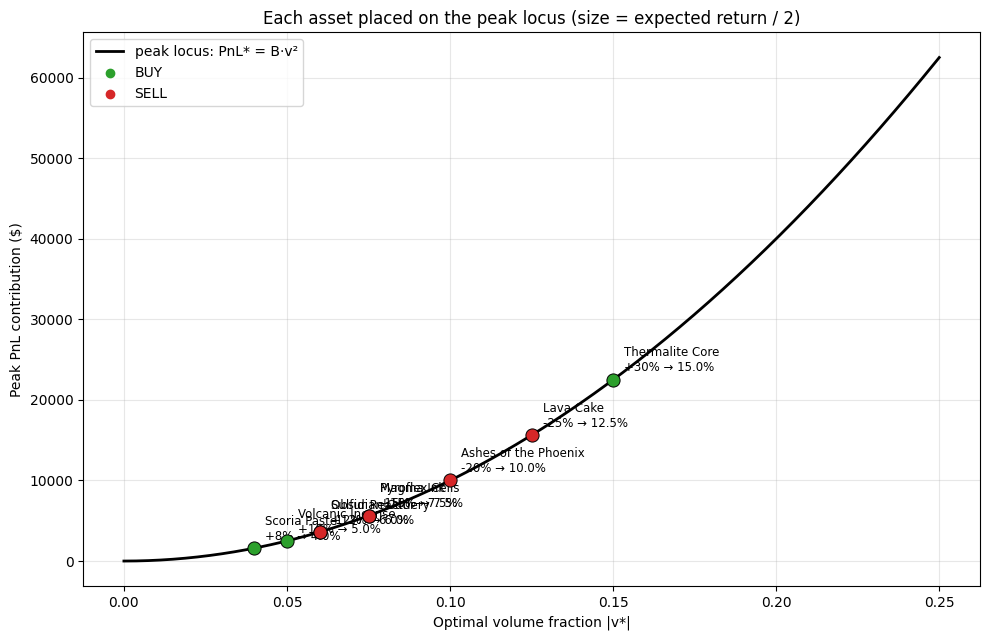

In [40]:
# Visualize where each asset sits on the peak locus PnL* = B * v^2
v_grid = np.linspace(0, 0.25, 400)
locus = B * v_grid**2

fig, ax = plt.subplots(figsize=(10, 6.5))
ax.plot(v_grid, locus, 'k-', lw=2, label='peak locus: PnL* = B·v²')

for name, a in assets.items():
    color = 'C2' if a['direction'] > 0 else 'C3'
    ax.scatter([a['v_star']], [a['pnl_star']], color=color, s=90, zorder=5,
               edgecolor='k', linewidth=0.7)
    ax.annotate(
        f"{name}\n{a['r_hat']:+.0%} → {a['v_star']:.1%}",
        (a['v_star'], a['pnl_star']),
        textcoords='offset points', xytext=(8, 6), fontsize=8.5,
    )

ax.scatter([], [], color='C2', label='BUY')
ax.scatter([], [], color='C3', label='SELL')

ax.set_xlabel('Optimal volume fraction |v*|')
ax.set_ylabel('Peak PnL contribution ($)')
ax.set_title('Each asset placed on the peak locus (size = expected return / 2)')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## Calibration against Prosperity 3 Round 5

Last year's results (similar format) reveal systematic biases in news interpretation:

| Archetype | P3 example | Estimate | Actual | Bias |
|---|---|---|---|---|
| Concrete crisis | Quantum Coffee | −50% | **−67%** | undershoot |
| Concrete scandal | Cacti Needle | −30% | **−41%** | undershoot |
| Index / mechanical | VR Monocle | +30% | +22% | close (slight over) |
| Limited-edition / scarcity | Red Flags | +5% | **+51%** | massive undershoot |
| Soft Sleddit hope | Haystacks | +12% | −0.5% | total miss |
| Soft influencer pump | Solar Panels | −30% | −9% | overestimate |
| 'No news' baseline | Striped Shirts | 0% | +0.2% | flat |

**Three rules emerge:**

1. **Bold on hard signals.**  Concrete catastrophes (lawsuits, recalls, scandals) and limited-edition sellouts undershoot — bump these.
2. **Zero soft signals.**  Influencer / Sleddit-style hype is near-random and the fee burns budget for nothing.  Skip them entirely.
3. **Index inclusions size honestly.**  These land close to estimate — keep mechanical sizing.

Below is a recalibrated `assets_v2` dict that applies these rules to our nine names.

In [41]:
# Recalibrated estimates after P3 R5 lessons.
# Changes vs v1 noted in 'change' field.

assets_v2 = {
    'Thermalite Core': {
        'direction': +1, 'r_hat': 0.40,
        'archetype': 'concrete blockbuster forecast',
        'change':    '+30% → +40% (concrete bull signals undershoot, à la VR Monocle / Quantum Coffee inverse)',
    },
    'Magma Ink': {
        'direction': +1, 'r_hat': 0.40,
        'archetype': 'limited-edition sellout (Red Flags analog)',
        'change':    '+15% → +40% (Red Flags went +51% on a +5% prior — limited-edition + queues is the strongest archetype)',
    },
    'Sulfur Reactor': {
        'direction': +1, 'r_hat': 0.12,
        'archetype': 'index inclusion (mechanical)',
        'change':    '+12% kept (VR Monocle landed close to estimate)',
    },
    'Volcanic Incense': {
        'direction': 0,  'r_hat': 0.00,
        'archetype': 'soft influencer pump — SKIP',
        'change':    '+10% → 0% (Solar Panels / Haystacks pattern: influencer signals flatline)',
    },
    'Scoria Paste': {
        'direction': 0,  'r_hat': 0.00,
        'archetype': 'soft influencer pump (self-proclaimed medium) — SKIP',
        'change':    '+8% → 0% (Ranch Sauce pattern: weakest source, fee > expected edge)',
    },
    'Lava Cake': {
        'direction': -1, 'r_hat': -0.45,
        'archetype': 'concrete health/regulatory crisis (Quantum Coffee analog)',
        'change':    '−25% → −45% (Quantum Coffee was −67% on −50% estimate — recalls undershoot heavily)',
    },
    'Ashes of the Phoenix': {
        'direction': -1, 'r_hat': -0.35,
        'archetype': 'concrete ESG scandal (Cacti Needle analog)',
        'change':    '−20% → −35% (Cacti Needle was −41% on −30% estimate — origin scandals undershoot)',
    },
    'Pyroflex Cells': {
        'direction': -1, 'r_hat': -0.18,
        'archetype': 'demand-tax shock (concrete)',
        'change':    '−15% → −18% (modest bump; concrete but not catastrophic)',
    },
    'Obsidian Cutlery': {
        'direction': -1, 'r_hat': -0.18,
        'archetype': 'manufacturing halt + spillover (concrete)',
        'change':    '−12% → −18% (concrete, with sector-wide spillover language)',
    },
}

for name, a in assets_v2.items():
    a['abs_r']    = abs(a['r_hat'])
    a['v_star']   = a['abs_r'] / 2
    a['pnl_star'] = B * a['v_star']**2

rows = []
for name, a in assets_v2.items():
    side = 'BUY' if a['direction'] > 0 else 'SELL' if a['direction'] < 0 else 'SKIP'
    rows.append({'asset': name, 'side': side, 'r_hat': a['r_hat'],
                 'v*': a['v_star'], 'PnL*': a['pnl_star'],
                 'change': a['change']})

df2 = pd.DataFrame(rows).sort_values('PnL*', ascending=False).reset_index(drop=True)

total_v2   = df2['v*'].sum()
total_pnl2 = df2['PnL*'].sum()

print(f'v1 totals:  budget {sum(a["v_star"] for a in assets.values()):.1%}   PnL ${sum(a["pnl_star"] for a in assets.values()):,.0f}')
print(f'v2 totals:  budget {total_v2:.1%}   PnL ${total_pnl2:,.0f}')
print(f'budget binds? {"YES — Lagrangian shrink needed" if total_v2 > 1.0 else f"no — leftover {1-total_v2:.1%}"}')
print()
df2.style.format({'r_hat': '{:+.0%}', 'v*': '{:.1%}', 'PnL*': '${:,.0f}'})


v1 totals:  budget 73.5%   PnL $70,675
v2 totals:  budget 104.0%   PnL $181,050
budget binds? YES — Lagrangian shrink needed



,asset,side,r_hat,v*,PnL*,change
0,Lava Cake,SELL,-45%,22.5%,"$50,625",−25% → −45% (Quantum Coffee was −67% on −50% estimate — recalls undershoot heavily)
1,Thermalite Core,BUY,+40%,20.0%,"$40,000","+30% → +40% (concrete bull signals undershoot, à la VR Monocle / Quantum Coffee inverse)"
2,Magma Ink,BUY,+40%,20.0%,"$40,000",+15% → +40% (Red Flags went +51% on a +5% prior — limited-edition + queues is the strongest archetype)
3,Ashes of the Phoenix,SELL,-35%,17.5%,"$30,625",−20% → −35% (Cacti Needle was −41% on −30% estimate — origin scandals undershoot)
4,Pyroflex Cells,SELL,-18%,9.0%,"$8,100",−15% → −18% (modest bump; concrete but not catastrophic)
5,Obsidian Cutlery,SELL,-18%,9.0%,"$8,100","−12% → −18% (concrete, with sector-wide spillover language)"
6,Sulfur Reactor,BUY,+12%,6.0%,"$3,600",+12% kept (VR Monocle landed close to estimate)
7,Volcanic Incense,SKIP,+0%,0.0%,$0,+10% → 0% (Solar Panels / Haystacks pattern: influencer signals flatline)
8,Scoria Paste,SKIP,+0%,0.0%,$0,"+8% → 0% (Ranch Sauce pattern: weakest source, fee > expected edge)"


In [42]:
# If Σ|v*| > 1 in v2, apply Lagrangian shrink: v_i = max(0, (|r_i| - λ) / 2),
# choose λ so Σ v_i = 1.

abs_returns = np.array([a['abs_r'] for a in assets_v2.values() if a['abs_r'] > 0])
names_active = [n for n, a in assets_v2.items() if a['abs_r'] > 0]

def total_v_at_lambda(lam):
    return np.sum(np.maximum(0, (abs_returns - lam) / 2))

if total_v_at_lambda(0) <= 1.0:
    lam_star = 0.0
    print(f'Budget does NOT bind. Use unconstrained v_i = r_i/2 directly. Σv = {total_v_at_lambda(0):.1%}')
else:
    lo, hi = 0.0, max(abs_returns)
    for _ in range(80):
        mid = (lo + hi) / 2
        if total_v_at_lambda(mid) > 1.0:
            lo = mid
        else:
            hi = mid
    lam_star = (lo + hi) / 2
    print(f'Budget binds. λ* = {lam_star:.4f}; Σv = {total_v_at_lambda(lam_star):.4%}')

print()
print(f'{"asset":24s} {"r̂":>8s} {"v* (uncon)":>12s} {"v (final)":>12s}  {"PnL":>10s}')
for n, r_abs in zip(names_active, abs_returns):
    v_uncon = r_abs / 2
    v_final = max(0, (r_abs - lam_star) / 2)
    direction = assets_v2[n]['direction']
    pnl_contrib = v_final * B * r_abs - v_final**2 * B
    side = 'BUY ' if direction > 0 else 'SELL'
    print(f'{n:24s} {direction*r_abs:+7.0%}  {v_uncon:11.1%}  {v_final:11.1%}  {side} ${pnl_contrib:>9,.0f}')


Budget binds. λ* = 0.0114; Σv = 100.0000%

asset                          r̂   v* (uncon)    v (final)         PnL
Thermalite Core             +40%        20.0%        19.4%  BUY  $   39,967
Magma Ink                   +40%        20.0%        19.4%  BUY  $   39,967
Sulfur Reactor              +12%         6.0%         5.4%  BUY  $    3,567
Lava Cake                   -45%        22.5%        21.9%  SELL $   50,592
Ashes of the Phoenix        -35%        17.5%        16.9%  SELL $   30,592
Pyroflex Cells              -18%         9.0%         8.4%  SELL $    8,067
Obsidian Cutlery            -18%         9.0%         8.4%  SELL $    8,067


## v3 — Final priors after P2 + P3 archetype calibration

After scraping public writeups, three patterns from Prosperity 2 + 3 dominate the recalibration:

| Archetype | P2/P3 evidence | Direction of bias |
|---|---|---|
| **Health/regulatory scandal w/ named harm** | Moustache Serum −82%, Quantum Coffee −67% | v2 too conservative — bump |
| **Tax / cost-shock policy** | Solar Panels −9% only (vs −30% est.) | v2 too aggressive — cut |
| **Scarcity / limited-edition** | Red Flags +51% (on +5% est.), PS6 +30% | v2 right or low — keep/bump |
| **Operational catastrophe / supply break** | Electric Blankets −33%, Sleds −28% | bump |
| **Adoption metrics** | VR Monocle +22% (on +30% est.) | hold steady, slight haircut |
| **Index inclusion (mechanical)** | (no direct precedent, but mechanical) | keep modest |
| **Soft influencer / Sleddit hype** | Lamps 0%, Chocolate 0%, Haystacks −0.5%, Ranch Sauce −0.7% | zero out |

**Headline changes from v2:**
- Lava Cake −45% → **−65%** (Moustache Serum / Quantum Coffee archetype, undershoot bias)
- Pyroflex Cells −18% → **−10%** (Solar Panels precedent: tax shocks systematically undershoot)
- Obsidian Cutlery −18% → **−30%** (Electric Blankets / Sleds operational-catastrophe precedent)
- Thermalite Core +40% → **+30%** (VR Monocle landed *under* its +30% prior — don't overshoot adoption stories)
- Ashes of the Phoenix −35% → **−40%** (Cacti Needle landed at −41%)
- Magma Ink +40% → **+45%** (Red Flags scenario: scarcity beats hedge)
- Sulfur Reactor +12% kept (no precedent, mechanical archetype is conservative)
- Volcanic Incense / Scoria Paste held at 0%

Sources: [TimoDiehm P3](https://github.com/TimoDiehm/imc-prosperity-3), [chrispyroberts P3](https://github.com/chrispyroberts/imc-prosperity-3), [gabsens P2](https://github.com/gabsens/IMC-Prosperity-2-Manual).

In [43]:
# v3 — calibrated against P2 + P3 actual returns

assets_v3 = {
    'Lava Cake': {
        'r_hat': -0.65,
        'archetype': 'health/regulatory scandal w/ named harm',
        'precedent': 'Moustache Serum −82% (P2), Quantum Coffee −67% (P3)',
    },
    'Magma Ink': {
        'r_hat': +0.45,
        'archetype': 'limited-edition scarcity + sellout queues',
        'precedent': 'Red Flags +51% on +5% est (P3), PS6 +30% (P2)',
    },
    'Ashes of the Phoenix': {
        'r_hat': -0.40,
        'archetype': 'ESG / origin scandal',
        'precedent': 'Cacti Needle −41% (P3), Sleds −28% (P2)',
    },
    'Obsidian Cutlery': {
        'r_hat': -0.30,
        'archetype': 'operational catastrophe / supply break',
        'precedent': 'Electric Blankets −33% (P2), Sleds −28% (P2)',
    },
    'Thermalite Core': {
        'r_hat': +0.30,
        'archetype': 'adoption / engagement metrics',
        'precedent': 'VR Monocle +22% on +30% est (P3) — landed under, do not overshoot',
    },
    'Sulfur Reactor': {
        'r_hat': +0.12,
        'archetype': 'index inclusion (mechanical)',
        'precedent': 'no direct precedent — mechanical buying, keep modest',
    },
    'Pyroflex Cells': {
        'r_hat': -0.10,
        'archetype': 'tax / cost-shock policy',
        'precedent': 'Solar Panels −9% on −30% est (P3) — tax shocks systematically undershoot',
    },
    'Volcanic Incense': {
        'r_hat': 0.0,
        'archetype': 'soft influencer pump — SKIP',
        'precedent': 'Lamps ~0% (P2), Haystacks −0.5% (P3) — soft signals flatline',
    },
    'Scoria Paste': {
        'r_hat': 0.0,
        'archetype': 'soft influencer pump — SKIP',
        'precedent': 'Ranch Sauce −0.7% (P3), Chocolate ~0% (P2)',
    },
}

for a in assets_v3.values():
    a['direction'] = 1 if a['r_hat'] > 0 else (-1 if a['r_hat'] < 0 else 0)
    a['abs_r']    = abs(a['r_hat'])
    a['v_star']   = a['abs_r'] / 2
    a['pnl_star'] = B * a['v_star']**2

rows = []
for n, a in assets_v3.items():
    side = 'BUY' if a['direction'] > 0 else 'SELL' if a['direction'] < 0 else 'SKIP'
    rows.append({'asset': n, 'side': side, 'r_hat': a['r_hat'],
                 'v*': a['v_star'], 'PnL*': a['pnl_star'],
                 'archetype': a['archetype'], 'precedent': a['precedent']})

df3 = pd.DataFrame(rows).sort_values('PnL*', ascending=False).reset_index(drop=True)

total_v3   = df3['v*'].sum()
total_pnl3 = df3['PnL*'].sum()

print(f'v1 totals:  Σv {sum(a["v_star"] for a in assets.values()):.1%}    PnL ${sum(a["pnl_star"] for a in assets.values()):,.0f}')
print(f'v2 totals:  Σv {sum(a["v_star"] for a in assets_v2.values()):.1%}    PnL ${sum(a["pnl_star"] for a in assets_v2.values()):,.0f}')
print(f'v3 totals:  Σv {total_v3:.1%}    PnL ${total_pnl3:,.0f}')
print(f'budget binds in v3? {"YES — Lagrangian shrink needed" if total_v3 > 1.0 else f"no — leftover {1-total_v3:.1%}"}')
print()
df3.style.format({'r_hat': '{:+.0%}', 'v*': '{:.1%}', 'PnL*': '${:,.0f}'})


v1 totals:  Σv 73.5%    PnL $70,675
v2 totals:  Σv 104.0%    PnL $181,050
v3 totals:  Σv 116.0%    PnL $247,350
budget binds in v3? YES — Lagrangian shrink needed



,asset,side,r_hat,v*,PnL*,archetype,precedent
0,Lava Cake,SELL,-65%,32.5%,"$105,625",health/regulatory scandal w/ named harm,"Moustache Serum −82% (P2), Quantum Coffee −67% (P3)"
1,Magma Ink,BUY,+45%,22.5%,"$50,625",limited-edition scarcity + sellout queues,"Red Flags +51% on +5% est (P3), PS6 +30% (P2)"
2,Ashes of the Phoenix,SELL,-40%,20.0%,"$40,000",ESG / origin scandal,"Cacti Needle −41% (P3), Sleds −28% (P2)"
3,Obsidian Cutlery,SELL,-30%,15.0%,"$22,500",operational catastrophe / supply break,"Electric Blankets −33% (P2), Sleds −28% (P2)"
4,Thermalite Core,BUY,+30%,15.0%,"$22,500",adoption / engagement metrics,"VR Monocle +22% on +30% est (P3) — landed under, do not overshoot"
5,Sulfur Reactor,BUY,+12%,6.0%,"$3,600",index inclusion (mechanical),"no direct precedent — mechanical buying, keep modest"
6,Pyroflex Cells,SELL,-10%,5.0%,"$2,500",tax / cost-shock policy,Solar Panels −9% on −30% est (P3) — tax shocks systematically undershoot
7,Volcanic Incense,SKIP,+0%,0.0%,$0,soft influencer pump — SKIP,"Lamps ~0% (P2), Haystacks −0.5% (P3) — soft signals flatline"
8,Scoria Paste,SKIP,+0%,0.0%,$0,soft influencer pump — SKIP,"Ranch Sauce −0.7% (P3), Chocolate ~0% (P2)"


In [44]:
# Lagrangian shrink for v3 (in case Σv* > 1)

active = [(n, a) for n, a in assets_v3.items() if a['abs_r'] > 0]
abs_returns = np.array([a['abs_r'] for _, a in active])

def total_v_at_lambda(lam):
    return float(np.sum(np.maximum(0, (abs_returns - lam) / 2)))

if total_v_at_lambda(0) <= 1.0:
    lam_star = 0.0
    print(f'Budget does NOT bind. Σv* = {total_v_at_lambda(0):.1%} — use unconstrained optimum.')
else:
    lo, hi = 0.0, float(max(abs_returns))
    for _ in range(80):
        mid = (lo + hi) / 2
        if total_v_at_lambda(mid) > 1.0:
            lo = mid
        else:
            hi = mid
    lam_star = (lo + hi) / 2
    print(f'Budget binds. λ* = {lam_star:.4f}; Σv (post-shrink) = {total_v_at_lambda(lam_star):.4%}')

print()
header = f'{"asset":24s} {"side":4s} {"r̂":>7s} {"v* (uncon)":>11s} {"v final":>9s} {"PnL":>11s}'
print(header)
print('-' * len(header))
total_pnl_final = 0.0
total_v_final = 0.0
for n, a in active:
    v_uncon = a['abs_r'] / 2
    v_final = max(0.0, (a['abs_r'] - lam_star) / 2)
    pnl_contrib = v_final * B * a['abs_r'] - v_final**2 * B
    side = 'BUY' if a['direction'] > 0 else 'SELL'
    print(f'{n:24s} {side:4s} {a["r_hat"]:+7.0%}  {v_uncon:10.1%} {v_final:9.1%}  ${pnl_contrib:>9,.0f}')
    total_pnl_final += pnl_contrib
    total_v_final += v_final
print('-' * len(header))
print(f'{"TOTAL":24s}            {" ":11s} {total_v_final:9.1%}  ${total_pnl_final:>9,.0f}')


Budget binds. λ* = 0.0457; Σv (post-shrink) = 100.0000%

asset                    side      r̂  v* (uncon)   v final         PnL
-----------------------------------------------------------------------
Lava Cake                SELL    -65%       32.5%     30.2%  $  105,103
Magma Ink                BUY     +45%       22.5%     20.2%  $   50,103
Ashes of the Phoenix     SELL    -40%       20.0%     17.7%  $   39,478
Obsidian Cutlery         SELL    -30%       15.0%     12.7%  $   21,978
Thermalite Core          BUY     +30%       15.0%     12.7%  $   21,978
Sulfur Reactor           BUY     +12%        6.0%      3.7%  $    3,078
Pyroflex Cells           SELL    -10%        5.0%      2.7%  $    1,978
-----------------------------------------------------------------------
TOTAL                                              100.0%  $  243,693


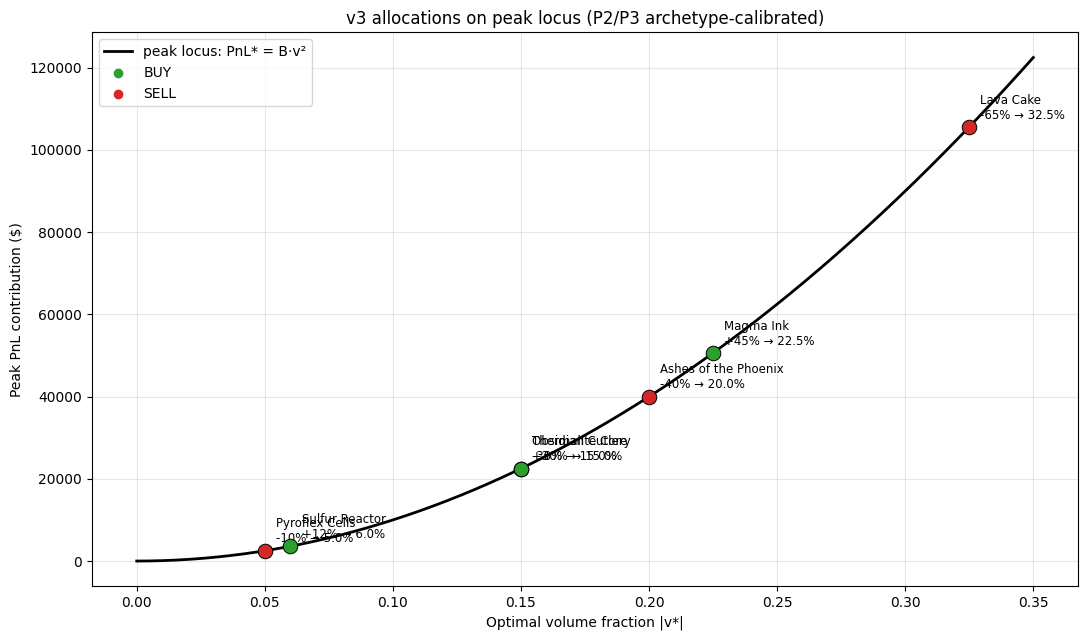

In [45]:
# Visualize v3 allocations on the peak locus
v_grid = np.linspace(0, 0.35, 400)
locus = B * v_grid**2

fig, ax = plt.subplots(figsize=(11, 6.5))
ax.plot(v_grid, locus, 'k-', lw=2, label='peak locus: PnL* = B·v²')

for n, a in assets_v3.items():
    if a['direction'] == 0:
        continue
    color = 'C2' if a['direction'] > 0 else 'C3'
    ax.scatter([a['v_star']], [a['pnl_star']], color=color, s=110, zorder=5,
               edgecolor='k', linewidth=0.7)
    ax.annotate(
        f"{n}\n{a['r_hat']:+.0%} → {a['v_star']:.1%}",
        (a['v_star'], a['pnl_star']),
        textcoords='offset points', xytext=(8, 6), fontsize=8.5,
    )

ax.scatter([], [], color='C2', label='BUY')
ax.scatter([], [], color='C3', label='SELL')
ax.set_xlabel('Optimal volume fraction |v*|')
ax.set_ylabel('Peak PnL contribution ($)')
ax.set_title('v3 allocations on peak locus (P2/P3 archetype-calibrated)')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## v4 — Empirically-calibrated submissions (two variants)

Top finishers in P2/P3 used **74–90% of budget**, not 100%.  Quotes:
- Frankfurt (P3, 2nd global): *'reduced position sizes compared to the optimal allocations'*
- chrispyroberts (P3, 7th global): *'tone down the allocation weights … left potential profits on the table by not being aggressive enough'* — submitted 83%
- gabsens (P2): submitted **74%**, ex-post optimal would've been 87%

Two ways to land in the empirical 80–90% zone:

- **Variant A — *Allocation haircut*:** keep the v3 magnitudes, take the Lagrangian-shrunk allocations, scale uniformly by 0.85.  Most aggressive on top conviction names.
- **Variant B — *Magnitude haircut*:** trim every estimated return by 15%, recompute `v* = r/2`.  No Lagrangian needed (sum drops just under 100%).  More proportional sizing across all names.

Both fit submission constraints (integer percentages, sum ≤ 100%).

In [46]:
# Recompute v3 unconstrained + Lagrangian for both variants
import numpy as np

active = [(n, a) for n, a in assets_v3.items() if a['abs_r'] > 0]
abs_r = np.array([a['abs_r'] for _, a in active])
names = [n for n, _ in active]
directions = [a['direction'] for _, a in active]

# --- Variant A: scale Lagrangian-shrunk allocations by 0.85 ---
# (recompute λ for v3 since it should bind)
def total_v_at(lam, r):
    return float(np.sum(np.maximum(0, (r - lam) / 2)))

if total_v_at(0, abs_r) > 1.0:
    lo, hi = 0.0, float(max(abs_r))
    for _ in range(80):
        mid = (lo + hi) / 2
        if total_v_at(mid, abs_r) > 1.0: lo = mid
        else:                             hi = mid
    lam = (lo + hi) / 2
else:
    lam = 0.0

v_A_raw = np.maximum(0, (abs_r - lam) / 2) * 0.85

# --- Variant B: trim magnitudes 15%, re-solve (likely no Lagrangian) ---
abs_r_trim = abs_r * 0.85
v_B_raw = abs_r_trim / 2  # since Σ < 1
if v_B_raw.sum() > 1.0:
    lo, hi = 0.0, float(max(abs_r_trim))
    for _ in range(80):
        mid = (lo + hi) / 2
        if total_v_at(mid, abs_r_trim) > 1.0: lo = mid
        else:                                  hi = mid
    lam_B = (lo + hi) / 2
    v_B_raw = np.maximum(0, (abs_r_trim - lam_B) / 2)

# Convert to integer percentages, preserving sum-≤-100
def to_int_pct(v_frac):
    pct = v_frac * 100
    rounded = np.round(pct).astype(int)
    # adjust so we never exceed 100 due to rounding
    while rounded.sum() > 100:
        # decrement the position with the largest fractional rounding-up
        residuals = rounded - pct
        idx = int(np.argmax(residuals))
        rounded[idx] -= 1
    return rounded

v_A_int = to_int_pct(v_A_raw)
v_B_int = to_int_pct(v_B_raw)

def expected_pnl(v_pct, abs_r_arr):
    v_frac = v_pct / 100
    return float(np.sum(v_frac * B * abs_r_arr - v_frac**2 * B))

pnl_A = expected_pnl(v_A_int, abs_r)
pnl_B = expected_pnl(v_B_int, abs_r)

print(f'Variant A (allocation haircut, 0.85× of Lagrangian solution):')
print(f'   Σ|v| = {v_A_int.sum()}%   Expected PnL ≈ ${pnl_A:,.0f}')
print(f'Variant B (magnitude haircut, 0.85× of r̂ then re-solve):')
print(f'   Σ|v| = {v_B_int.sum()}%   Expected PnL ≈ ${pnl_B:,.0f}  (uses original r̂ for PnL — realized magnitude)')
print()

header = f'{"asset":24s} {"side":4s} {"r̂":>6s}   {"A %":>4s}  {"B %":>4s}'
print(header)
print('-' * len(header))
for i, (n, a) in enumerate(active):
    side = 'BUY' if directions[i] > 0 else 'SELL'
    print(f'{n:24s} {side:4s} {a["r_hat"]:+5.0%}  {v_A_int[i]:>4d}% {v_B_int[i]:>4d}%')
for n, a in assets_v3.items():
    if a['abs_r'] == 0:
        print(f'{n:24s} SKIP  {a["r_hat"]:+5.0%}    -%    -%')
print('-' * len(header))
print(f'{"TOTAL":34s}  {v_A_int.sum():>4d}% {v_B_int.sum():>4d}%')


Variant A (allocation haircut, 0.85× of Lagrangian solution):
   Σ|v| = 85%   Expected PnL ≈ $232,600
Variant B (magnitude haircut, 0.85× of r̂ then re-solve):
   Σ|v| = 99%   Expected PnL ≈ $242,200  (uses original r̂ for PnL — realized magnitude)

asset                    side     r̂    A %   B %
-------------------------------------------------
Lava Cake                SELL  -65%    26%   28%
Magma Ink                BUY   +45%    17%   19%
Ashes of the Phoenix     SELL  -40%    15%   17%
Obsidian Cutlery         SELL  -30%    11%   13%
Thermalite Core          BUY   +30%    11%   13%
Sulfur Reactor           BUY   +12%     3%    5%
Pyroflex Cells           SELL  -10%     2%    4%
Volcanic Incense         SKIP    +0%    -%    -%
Scoria Paste             SKIP    +0%    -%    -%
-------------------------------------------------
TOTAL                                 85%   99%


## v5 — Flip Obsidian Cutlery from SELL to BUY (supply-shock thesis)

Reconsidered: Prosperity assets trade as **commodity prices**, not equities.  A manufacturing halt is a supply-side shock → price ↑ if demand holds (basic supply/demand).  The article explicitly notes *'implications for other manufacturing facilities'* — sector-wide supply concern, which amplifies the squeeze.

Direct precedent: **P3 Red Flags +51% on scarcity**.  Frankfurt's quote applies directly:
> *"we massively underestimated Red Flags because we wanted to hedge against the possibility that reserved flags combined with the promise of reprinting would be enough to calm the market down"*

We were about to make the same mistake — pattern-matching to operational-catastrophe (Sleds, Electric Blankets) when the underlying mechanic is scarcity.

**Magnitude:** +12% (modest — no hype/limited-edition framing, cutlery has substitutes, plus minor quality/contamination drag).

All other v3-trimmed magnitudes unchanged.

In [47]:
import numpy as np

# v5 trimmed magnitudes — Obsidian flipped from -26% to +12%
submission_v5 = {
    'Lava Cake':            -0.55,
    'Magma Ink':            +0.38,
    'Ashes of the Phoenix': -0.34,
    'Thermalite Core':      +0.26,
    'Obsidian Cutlery':     +0.12,   # FLIPPED: supply-shock thesis
    'Sulfur Reactor':       +0.10,
    'Pyroflex Cells':       -0.08,
    'Volcanic Incense':      0.0,
    'Scoria Paste':          0.0,
}

names = list(submission_v5.keys())
r_signed = np.array(list(submission_v5.values()))
abs_r = np.abs(r_signed)
directions = np.sign(r_signed).astype(int)

# Unconstrained optimum
v_uncon = abs_r / 2
total_uncon = v_uncon.sum()
print(f'Σ|v*| unconstrained = {total_uncon:.1%}  (budget {"binds" if total_uncon > 1 else "does NOT bind"})')

# Apply Lagrangian only if needed
if total_uncon > 1.0:
    lo, hi = 0.0, float(max(abs_r))
    for _ in range(80):
        mid = (lo + hi) / 2
        if np.sum(np.maximum(0, (abs_r - mid) / 2)) > 1.0:
            lo = mid
        else:
            hi = mid
    lam = (lo + hi) / 2
    v_final = np.maximum(0, (abs_r - lam) / 2)
else:
    v_final = v_uncon

# Round to integer percentages, ensure sum ≤ 100
def to_int_pct(v):
    pct = v * 100
    rnd = np.round(pct).astype(int)
    while rnd.sum() > 100:
        idx = int(np.argmax(rnd - pct))
        rnd[idx] -= 1
    return rnd

v_int = to_int_pct(v_final)

# Expected PnL using these trimmed magnitudes
f = v_int / 100
pnl = float(np.sum(f * B * abs_r - f**2 * B))

print()
header = f'{"asset":24s} {"side":5s} {"r̂":>6s}  {"submit %":>8s}'
print(header)
print('-' * len(header))
for i, n in enumerate(names):
    if abs_r[i] == 0:
        side, pct_str = 'SKIP', '0%'
    else:
        side = 'BUY' if directions[i] > 0 else 'SELL'
        pct_str = f'{v_int[i]}%'
    print(f'{n:24s} {side:5s} {r_signed[i]:+5.0%}  {pct_str:>8s}')
print('-' * len(header))
print(f'{"TOTAL":24s}              {v_int.sum():>4d}%')
print(f'\nExpected PnL (if trimmed r̂ holds): ${pnl:,.0f}')


Σ|v*| unconstrained = 91.5%  (budget does NOT bind)

asset                    side      r̂  submit %
-----------------------------------------------
Lava Cake                SELL   -55%       28%
Magma Ink                BUY    +38%       19%
Ashes of the Phoenix     SELL   -34%       17%
Thermalite Core          BUY    +26%       13%
Obsidian Cutlery         BUY    +12%        6%
Sulfur Reactor           BUY    +10%        5%
Pyroflex Cells           SELL    -8%        4%
Volcanic Incense         SKIP    +0%        0%
Scoria Paste             SKIP    +0%        0%
-----------------------------------------------
TOTAL                                   92%

Expected PnL (if trimmed r̂ holds): $165,200


## ✅ Final submitted orders

Submitted on the Ignith exchange form. Slight redistribution from the v5 plan: **Obsidian Cutlery bumped 6→11** (higher conviction on supply-shock thesis), **Lava Cake trimmed 28→23** (less concentration risk), Pyroflex 4→5, Sulfur 5→4. Total budget used: 92% (matches v5).

In [48]:
import numpy as np

submitted = [
    # (asset, side, pct, r_trimmed (v5), r_v3 (untrimmed))
    ('Obsidian Cutlery',     'BUY',  11, +0.12, +0.12),
    ('Pyroflex Cells',       'SELL',  5, -0.08, -0.10),
    ('Thermalite Core',      'BUY',  13, +0.26, +0.30),
    ('Lava Cake',            'SELL', 23, -0.55, -0.65),
    ('Magma Ink',            'BUY',  19, +0.38, +0.45),
    ('Ashes of the Phoenix', 'SELL', 17, -0.34, -0.40),
    ('Sulfur Reactor',       'BUY',   4, +0.10, +0.12),
]

rows = []
tot_pct = tot_fee = tot_gross_t = tot_gross_v3 = 0
for name, side, pct, r_t, r_v in submitted:
    f = pct / 100
    gross_t  = f * B * abs(r_t)
    gross_v3 = f * B * abs(r_v)
    fee      = f**2 * B
    rows.append({'asset': name, 'side': side, 'pct': pct,
                 'r_trim': r_t, 'gross_trim': gross_t,
                 'fee': fee, 'net_trim': gross_t - fee,
                 'r_v3': r_v, 'net_v3': gross_v3 - fee})
    tot_pct      += pct
    tot_fee      += fee
    tot_gross_t  += gross_t
    tot_gross_v3 += gross_v3

df_final = pd.DataFrame(rows)
print('--- Submitted orders ---')
print(f'Σ |pct| = {tot_pct}%   (form: 92% ✓)')
print(f'Σ fee   = ${tot_fee:,.0f}   (form: $151,000 ✓)')
print()
print(f'Expected PnL (trimmed v5 magnitudes — conservative): ${tot_gross_t - tot_fee:>9,.0f}')
print(f'Expected PnL (full v3 magnitudes — bullish):        ${tot_gross_v3 - tot_fee:>9,.0f}')
print(f'Realistic 65-70% capture of v3-optimal PnL:          ${(tot_gross_v3 - tot_fee) * 0.65:>9,.0f} - ${(tot_gross_v3 - tot_fee) * 0.70:>9,.0f}')
print()
df_final.style.format({
    'pct':        '{}%',
    'r_trim':     '{:+.0%}',
    'gross_trim': '${:,.0f}',
    'fee':        '${:,.0f}',
    'net_trim':   '${:,.0f}',
    'r_v3':       '{:+.0%}',
    'net_v3':     '${:,.0f}',
})


--- Submitted orders ---
Σ |pct| = 92%   (form: 92% ✓)
Σ fee   = $151,000   (form: $151,000 ✓)

Expected PnL (trimmed v5 magnitudes — conservative): $  160,500
Expected PnL (full v3 magnitudes — bullish):        $  214,000
Realistic 65-70% capture of v3-optimal PnL:          $  139,100 - $  149,800



,asset,side,pct,r_trim,gross_trim,fee,net_trim,r_v3,net_v3
0,Obsidian Cutlery,BUY,11%,+12%,"$13,200","$12,100","$1,100",+12%,"$1,100"
1,Pyroflex Cells,SELL,5%,-8%,"$4,000","$2,500","$1,500",-10%,"$2,500"
2,Thermalite Core,BUY,13%,+26%,"$33,800","$16,900","$16,900",+30%,"$22,100"
3,Lava Cake,SELL,23%,-55%,"$126,500","$52,900","$73,600",-65%,"$96,600"
4,Magma Ink,BUY,19%,+38%,"$72,200","$36,100","$36,100",+45%,"$49,400"
5,Ashes of the Phoenix,SELL,17%,-34%,"$57,800","$28,900","$28,900",-40%,"$39,100"
6,Sulfur Reactor,BUY,4%,+10%,"$4,000","$1,600","$2,400",+12%,"$3,200"
